<a href="https://colab.research.google.com/github/redwan95/Circuity_Analysis_Chicago/blob/main/Final_Analysis_Heat_Intensity_and_Power_Outage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final Code for the Analysis, Mapping and Statitical Evaluation is below -**

✅ Imports done
✅ Config set. EAGLE_DIR = /content/eaglei_outages

🚀 Texas heatwave–outage event analysis (2014–2021) starting...

📂 Listing files in EAGLE_DIR: /content/eaglei_outages
 -> ['eaglei_outages_2021.csv', 'eaglei_outages_2020.csv', 'eaglei_outages_2019.csv', 'eaglei_outages_2015.csv', 'eaglei_outages_2018.csv', 'eaglei_outages_2017.csv', 'eaglei_outages_2016.csv', 'eaglei_outages_2014.csv']

🔍 Checking /content/eaglei_outages/eaglei_outages_2014.csv
📥 Loading /content/eaglei_outages/eaglei_outages_2014.csv ...

🔍 Checking /content/eaglei_outages/eaglei_outages_2015.csv
📥 Loading /content/eaglei_outages/eaglei_outages_2015.csv ...

🔍 Checking /content/eaglei_outages/eaglei_outages_2016.csv
📥 Loading /content/eaglei_outages/eaglei_outages_2016.csv ...

🔍 Checking /content/eaglei_outages/eaglei_outages_2017.csv
📥 Loading /content/eaglei_outages/eaglei_outages_2017.csv ...

🔍 Checking /content/eaglei_outages/eaglei_outages_2018.csv
📥 Loading /content/eaglei_outages/eaglei_outage

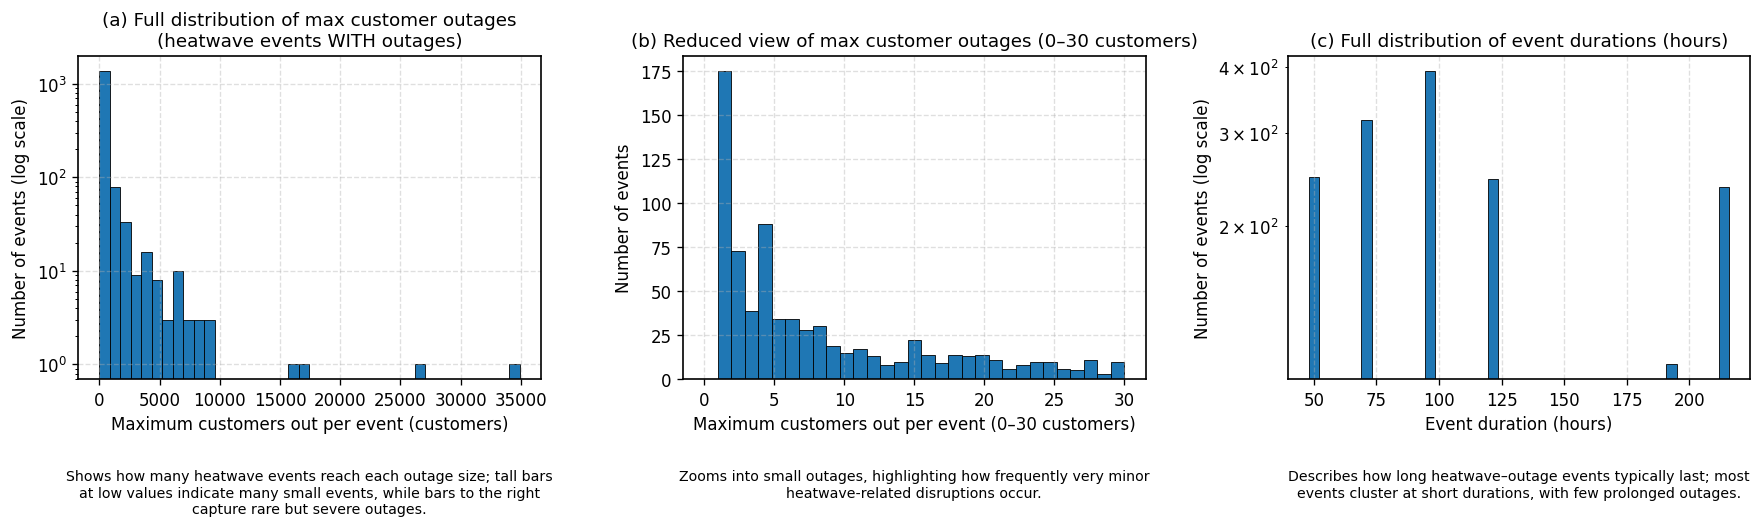

📦 Using existing shapefile zip: /content/cb_2018_us_county_500k.zip
💾 Saved map 1 to: /content/tx_heatwave_outage_map_n_events.png


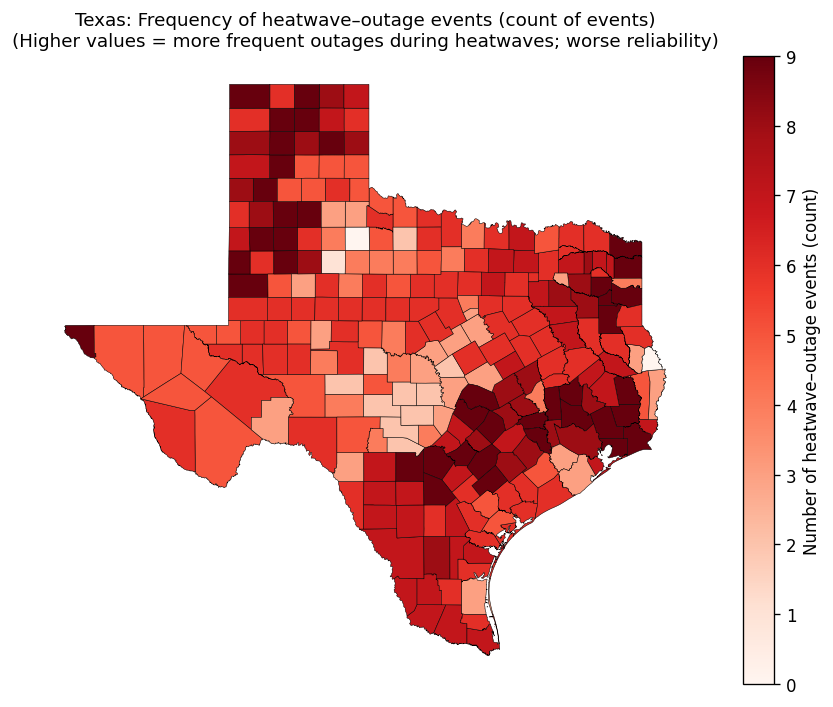


📊 Customers map scaling: min=0.0, max=58356.0, 90th percentile cap=6143.7
💾 Saved map 2 to: /content/tx_heatwave_outage_map_customers.png


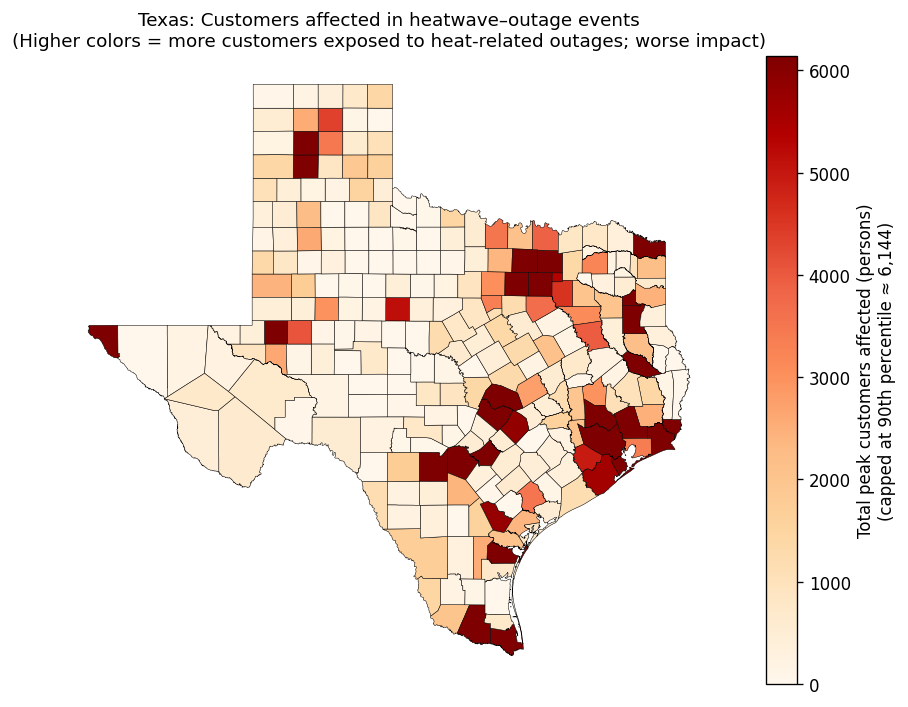

💾 Saved map 3 to: /content/tx_heatwave_outage_map_duration.png


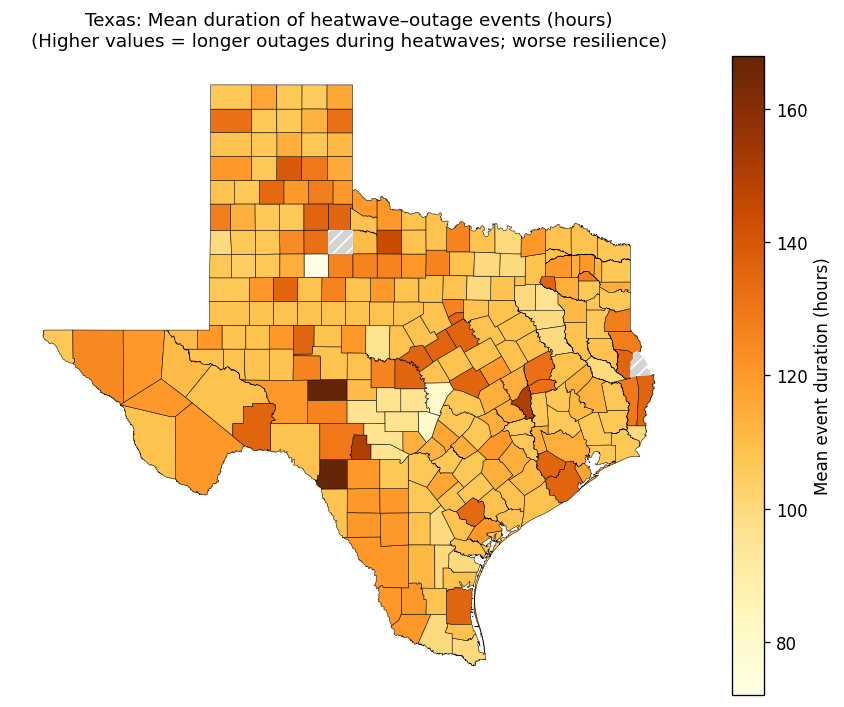


✅ Done.
90th percentile of max_customers: 347.3
95th percentile of max_customers: 1047.1

Threshold: P90 severity  (cutoff = 347.3 customers)
                           Logit Regression Results                           
Dep. Variable:               is_major   No. Observations:                 3048
Model:                          Logit   Df Residuals:                     3046
Method:                           MLE   Df Model:                            1
Date:                Tue, 25 Nov 2025   Pseudo R-squ.:                 0.03468
Time:                        21:04:10   Log-Likelihood:                -956.91
converged:                       True   LL-Null:                       -991.29
Covariance Type:            nonrobust   LLR p-value:                 1.110e-16
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.3173      0.068    -34.082      

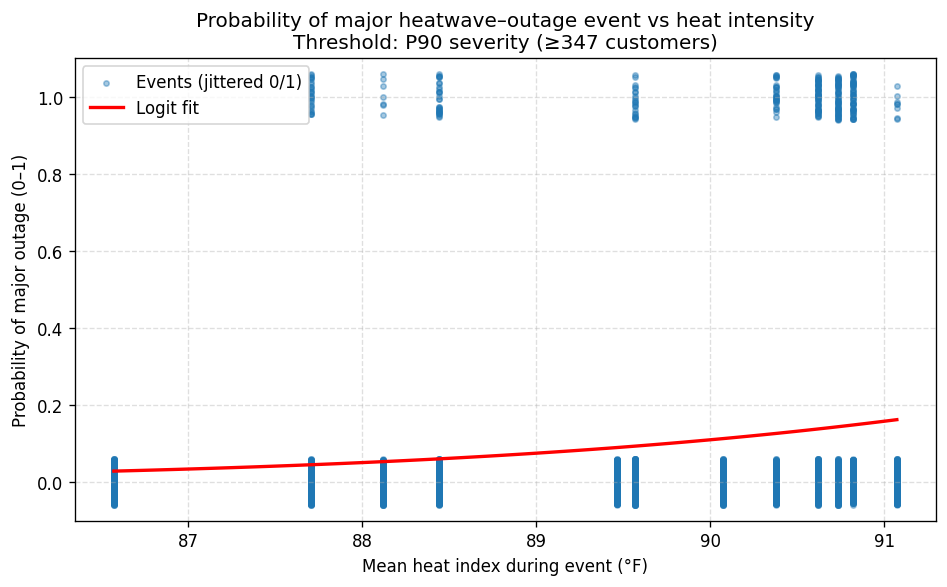


Threshold: P95 severity  (cutoff = 1047.1 customers)
                           Logit Regression Results                           
Dep. Variable:               is_major   No. Observations:                 3048
Model:                          Logit   Df Residuals:                     3046
Method:                           MLE   Df Model:                            1
Date:                Tue, 25 Nov 2025   Pseudo R-squ.:                 0.02215
Time:                        21:04:11   Log-Likelihood:                -593.40
converged:                       True   LL-Null:                       -606.84
Covariance Type:            nonrobust   LLR p-value:                 2.166e-07
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.0371      0.092    -33.164      0.000      -3.217      -2.858
mean_HI_centered     0.3545      0.074      4.778      0.00

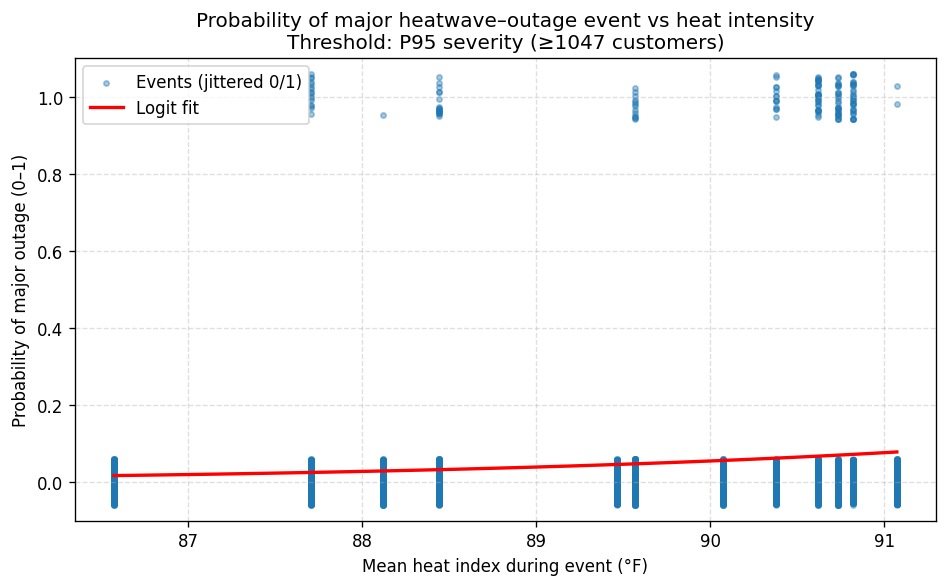


Threshold: Fixed 500 customers  (cutoff = 500.0 customers)
                           Logit Regression Results                           
Dep. Variable:               is_major   No. Observations:                 3048
Model:                          Logit   Df Residuals:                     3046
Method:                           MLE   Df Model:                            1
Date:                Tue, 25 Nov 2025   Pseudo R-squ.:                 0.03028
Time:                        21:04:12   Log-Likelihood:                -843.14
converged:                       True   LL-Null:                       -869.47
Covariance Type:            nonrobust   LLR p-value:                 3.972e-13
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.5197      0.074    -34.218      0.000      -2.664      -2.375
mean_HI_centered     0.3977      0.060      6.627    

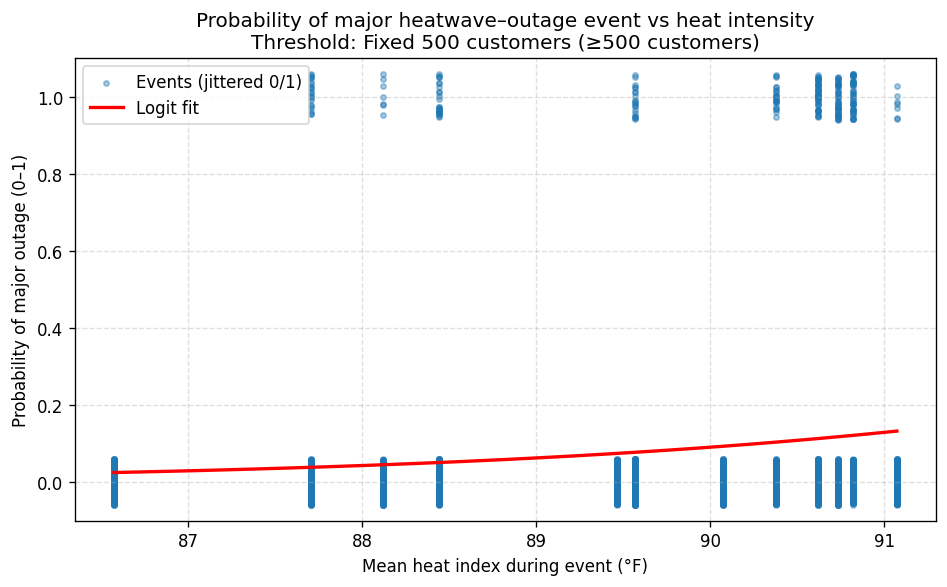

,threshold_label,cutoff_customers,OR_per_1F,OR_CI_low,OR_CI_high,p_value,McFadden_R2
0,P90 severity,347.3,1.520523,1.363609,1.695493,4.668560e-14,0.034684
1,P95 severity,1047.1,1.425479,1.232559,1.648595,1.768030e-06,0.022147
2,Fixed 500 customers,500.0,1.488444,1.323258,1.674251,3.427664e-11,0.030281


💾 Saved threshold comparison table to: /content/tx_major_outage_logit_threshold_summary.csv


In [ ]:
# =============================================================================
# Texas Heatwave – Power Outage Relationship (2014–2021)
#
# Clean, adaptive version:
# - EAGLE-I outages (Texas, 2014–2021; missing years auto-skipped)
# - Open-Meteo archive (central Texas) for hourly temp & RH
# - Heat index (°F)
# - Adaptive heatwave threshold:
#   * Warm-season days (May–Sep)
#   * Try HI_f_max quantiles [0.95, 0.90, 0.85, 0.80]
#   * Pick first threshold that gives ≥ MIN_HW_DAYS and ≥ MIN_OUTAGE_HW_DAYS
# - Heatwave events:
#   * Primary: ≥ 2 consecutive heatwave days
#   * Fallback: 1-day events if no multi-day outage events
# - Outputs:
#   1) tx_heatwave_events_2014_2021.(csv/xlsx)  (all heatwave events)
#   2) tx_heatwave_outage_events_2014_2021.(csv/xlsx)  (heatwave events with outages)
#   3) tx_heatwave_outage_county_summary_2014_2021.(csv/xlsx)
#   4) Distribution plots (single JPEG):
#      (a) Full max customers per event (log y)
#      (b) Max customers 0–30
#      (c) Full event durations (log y)
#   5) County maps (individual PNGs, with units in vertical legend):
#      - # of heatwave–outage events
#      - Total peak customers in heatwave–outage events (capped at 90th pct)
#      - Mean duration of heatwave–outage events
#   6) Major-outage logistic regressions for multiple thresholds,
#      with plots + comparison table.
# =============================================================================

!pip install -q pandas numpy matplotlib geopandas requests openpyxl statsmodels

import os
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import geopandas as gpd
import statsmodels.api as sm
from IPython.display import display

plt.rcParams["figure.dpi"] = 120
print("✅ Imports done")

# ------------------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------------------

EAGLE_DIR = "/content/eaglei_outages"  # <-- your folder with EAGLE-I CSVs
YEARS = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
TX_STATE_NAMES = ["Texas", "TX"]
TX_FIPS = "48"
WARM_MONTHS = [5, 6, 7, 8, 9]

# Adaptive heatwave selection criteria
MIN_HW_DAYS = 200          # minimum warm-season heatwave days desired
MIN_OUTAGE_HW_DAYS = 20    # want at least this many days with outages in heatwave days
HI_QUANTILES_TO_TRY = [0.95, 0.90, 0.85, 0.80]

# If absolutely nothing works, final fallback absolute threshold
ABS_HI_FALLBACK = 90.0  # °F

# Map config
CENSUS_COUNTY_ZIP = (
    "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_500k.zip"
)
STATE_LABEL = "Texas"

print("✅ Config set. EAGLE_DIR =", EAGLE_DIR)

# ------------------------------------------------------------------------------
# UTILITIES
# ------------------------------------------------------------------------------

def heat_index_f(temp_f, rh):
    """Heat index (°F) from T (°F) and RH (%)."""
    T = np.asarray(temp_f, dtype="float64")
    R = np.asarray(rh, dtype="float64")
    HI = (
        -42.379
        + 2.04901523 * T
        + 10.14333127 * R
        - 0.22475541 * T * R
        - 6.83783e-3 * T**2
        - 5.481717e-2 * R**2
        + 1.22874e-3 * T**2 * R
        + 8.5282e-4 * T * R**2
        - 1.99e-6 * T**2 * R**2
    )
    mask = (T < 80) | (R < 40)
    HI[mask] = T[mask]
    return HI


def dewpoint_from_temp_rh(temp_c, rh):
    """Dewpoint (°C) from T (°C) and RH (%)."""
    T = np.asarray(temp_c, dtype="float64")
    RH = np.asarray(rh, dtype="float64")
    a, b = 17.27, 237.7
    gamma = (a * T / (b + T)) + np.log(RH / 100.0)
    dp_c = (b * gamma) / (a - gamma)
    return dp_c


# ------------------------------------------------------------------------------
# 1. LOAD EAGLE-I OUTAGES (TEXAS)
# ------------------------------------------------------------------------------

def load_eagle_i_outages_for_texas(eagle_dir, years):
    print("\n📂 Listing files in EAGLE_DIR:", eagle_dir)
    if os.path.exists(eagle_dir):
        print(" ->", os.listdir(eagle_dir))
    else:
        print(" ⚠️ EAGLE_DIR does not exist!")

    dfs = []
    for yr in years:
        path = os.path.join(eagle_dir, f"eaglei_outages_{yr}.csv")
        print(f"\n🔍 Checking {path}")
        if not os.path.exists(path):
            print(f" ⚠️ Missing {path}, skipping this year.")
            continue

        print(f"📥 Loading {path} ...")
        df = pd.read_csv(path)

        required_cols = {"fips_code", "county", "state", "sum", "run_start_time"}
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"File {path} is missing columns: {missing}")

        df_tx = df[df["state"].isin(TX_STATE_NAMES)].copy()
        if df_tx.empty:
            print(" ⚠️ No Texas/TX rows found in this file.")
            continue

        df_tx["run_start_time"] = pd.to_datetime(df_tx["run_start_time"])
        dfs.append(df_tx)

    if not dfs:
        raise ValueError("No EAGLE-I data loaded for Texas. Check state names/paths.")

    outages = pd.concat(dfs, ignore_index=True)
    print(f"\n✅ Total EAGLE-I records (TX only, all years): {len(outages):,}")
    print(outages.head())
    return outages


def aggregate_to_hourly(outages):
    """Hourly peak outages per county."""
    outages["datetime_hour"] = outages["run_start_time"].dt.floor("h")
    hourly = (
        outages.groupby(["fips_code", "county", "state", "datetime_hour"], as_index=False)
        ["sum"]
        .max()
        .rename(columns={"sum": "outages_customers"})
    )
    print(f"✅ Hourly outage records (TX): {len(hourly):,}")
    print(hourly.head())
    return hourly


# ------------------------------------------------------------------------------
# 2. HOURLY WEATHER (OPEN-METEO, FULL YEARS)
# ------------------------------------------------------------------------------

def fetch_weather_for_texas_openmeteo(hourly_outages):
    """Pull 2014–2021 hourly weather (central TX) and replicate to all counties."""
    year_min = int(hourly_outages["datetime_hour"].dt.year.min())
    year_max = int(hourly_outages["datetime_hour"].dt.year.max())
    start = datetime(year_min, 1, 1)
    end = datetime(year_max, 12, 31)

    print(f"\n🌡 Open-Meteo weather range (FULL YEARS): {start} – {end}")
    start_date = start.strftime("%Y-%m-%d")
    end_date = end.strftime("%Y-%m-%d")

    lat_central, lon_central = 31.0, -99.0  # central Texas

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat_central,
        "longitude": lon_central,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relativehumidity_2m",
        "timezone": "UTC",
    }
    print("🌍 Requesting Open-Meteo:", url)
    print(" params:", params)

    resp = requests.get(url, params=params)
    resp.raise_for_status()
    data_json = resp.json()
    hourly = data_json.get("hourly", {})
    if not hourly or "time" not in hourly:
        print("⚠️ Open-Meteo JSON missing 'hourly.time'.")
        print("Raw JSON keys:", data_json.keys())
        raise ValueError("Open-Meteo returned no hourly data; cannot continue.")

    wx = pd.DataFrame(hourly)
    print("➡️ Raw Open-Meteo hourly shape:", wx.shape)

    wx["datetime_hour"] = pd.to_datetime(wx["time"])
    wx = wx.drop(columns=["time"])
    wx = wx.sort_values("datetime_hour").reset_index(drop=True)

    # Convert units + heat index
    wx["temp_c"] = wx["temperature_2m"]
    wx["temp_f"] = wx["temp_c"] * 9.0 / 5.0 + 32.0
    wx["humidity_pct"] = wx["relativehumidity_2m"]
    wx["dewpoint_c"] = dewpoint_from_temp_rh(wx["temp_c"], wx["humidity_pct"])
    wx["dewpoint_f"] = wx["dewpoint_c"] * 9.0 / 5.0 + 32.0
    wx["heat_index_f"] = heat_index_f(wx["temp_f"], wx["humidity_pct"])

    # Replicate to each county
    weather_list = []
    unique_fips = hourly_outages["fips_code"].unique()
    print(f"📌 Replicating weather for {len(unique_fips)} Texas counties")

    for fips in unique_fips:
        tmp = wx.copy()
        tmp["fips_code"] = fips
        weather_list.append(tmp)

    weather = pd.concat(weather_list, ignore_index=True)
    weather = weather[
        [
            "fips_code",
            "datetime_hour",
            "temp_f",
            "dewpoint_f",
            "humidity_pct",
            "heat_index_f",
        ]
    ]
    print(f"✅ Weather records (replicated per county): {len(weather):,}")
    print(weather.head())
    return weather


# ------------------------------------------------------------------------------
# 3. JOIN OUTAGES + WEATHER, HOURLY → DAILY
# ------------------------------------------------------------------------------

def build_hourly_joined(hourly_outages, weather):
    df = weather.merge(
        hourly_outages[["fips_code", "county", "datetime_hour", "outages_customers"]],
        on=["fips_code", "datetime_hour"],
        how="left",
    )
    df["outages_customers"] = df["outages_customers"].fillna(0)
    df = df.sort_values(["fips_code", "datetime_hour"]).reset_index(drop=True)

    df["new_outages"] = (
        df.groupby("fips_code")["outages_customers"]
        .diff()
        .fillna(0)
        .clip(lower=0)
    )

    print(f"\n✅ Final hourly joined rows: {len(df):,}")
    print(df.head())
    return df


def aggregate_to_daily(df_hourly):
    """Aggregate hourly to daily metrics per fips (ALL days)."""
    df = df_hourly.copy()
    df["date"] = df["datetime_hour"].dt.floor("D")

    daily = (
        df.groupby(["fips_code", "date"], as_index=False)
        .agg(
            temp_f_max=("temp_f", "max"),
            temp_f_mean=("temp_f", "mean"),
            HI_f_max=("heat_index_f", "max"),
            HI_f_mean=("heat_index_f", "mean"),
            n_hours_HI_95=("heat_index_f", lambda x: np.sum(x >= 95.0)),
            n_hours_HI_100=("heat_index_f", lambda x: np.sum(x >= 100.0)),
            new_outages_day=("new_outages", "sum"),
            max_outages_customers=("outages_customers", "max"),
        )
    )
    daily["month"] = pd.to_datetime(daily["date"]).dt.month

    print(f"\n✅ Daily records (TX, all months): {len(daily):,}")
    print(daily.head())
    return daily


# ------------------------------------------------------------------------------
# 4. ADAPTIVE HEATWAVE THRESHOLD + EVENT LABELS
# ------------------------------------------------------------------------------

def choose_adaptive_heat_threshold(daily):
    """Choose a single HI_f_max threshold for TX warm-season that yields some outage overlap."""
    daily = daily.copy()
    warm = daily[daily["month"].isin(WARM_MONTHS)].copy()
    warm = warm[warm["HI_f_max"].notna()]

    if warm.empty:
        print("⚠️ No warm-season days with valid HI_f_max; using absolute fallback.")
        return ABS_HI_FALLBACK, None

    print("\n📊 Exploring candidate heatwave thresholds (warm-season only):")
    chosen_thr = None
    chosen_q = None

    for q in HI_QUANTILES_TO_TRY:
        thr = warm["HI_f_max"].quantile(q)
        cand = warm[warm["HI_f_max"] >= thr]
        n_days = len(cand)
        n_days_out = (cand["new_outages_day"] > 0).sum()
        print(
            f" q={q:.2f}, thr={thr:.2f}°F -> "
            f"{n_days} heat days, {n_days_out} heat days with outages"
        )

        if (n_days >= MIN_HW_DAYS) and (n_days_out >= MIN_OUTAGE_HW_DAYS):
            chosen_thr = thr
            chosen_q = q
            break

    if chosen_thr is None:
        print(
            f"⚠️ None of the quantiles met criteria "
            f"(MIN_HW_DAYS={MIN_HW_DAYS}, MIN_OUTAGE_HW_DAYS={MIN_OUTAGE_HW_DAYS})."
        )
        thr = warm["HI_f_max"].quantile(0.8)
        chosen_thr, chosen_q = thr, 0.8
        print(f" → Using fallback q=0.80, thr={thr:.2f}°F")

    print(
        f"\n✅ Chosen heatwave threshold: HI_f_max >= {chosen_thr:.2f}°F (q={chosen_q})"
    )
    return chosen_thr, chosen_q


def add_heatwave_flags(daily, hi_threshold):
    daily = daily.copy()
    daily["is_heatwave_day"] = (
        daily["month"].isin(WARM_MONTHS) & (daily["HI_f_max"] >= hi_threshold)
    )
    n_hw = int(daily["is_heatwave_day"].sum())
    n_hw_out = int(
        (daily["is_heatwave_day"] & (daily["new_outages_day"] > 0)).sum()
    )
    print(
        f"\n✅ Heatwave-day diagnostics: {n_hw} total heatwave days, "
        f"{n_hw_out} of them with outages."
    )
    return daily


def label_heatwave_events(daily, min_days_primary=2):
    """
    Label contiguous heatwave events per county.
    - First, build contiguous runs of heatwave days (is_heatwave_day).
    - Keep runs with length >= min_days_primary.
    - If that yields no events with outages, fall back to min_days=1.
    """
    if daily.empty:
        print("⚠️ Daily table empty; no heatwave events.")
        daily["heat_event_id"] = 0
        return daily, pd.DataFrame(), pd.DataFrame()

    daily = daily.sort_values(["fips_code", "date"]).copy()

    def _build_events(daily_in, min_days):
        daily_local = daily_in.copy()
        daily_local["heat_event_id"] = 0
        current_event_id = 0

        for fips, idxs in daily_local.groupby("fips_code").groups.items():
            sub_idx = daily_local.loc[idxs].sort_values("date").index
            prev_is_hw = False
            prev_date = None

            for idx in sub_idx:
                row = daily_local.loc[idx]
                if row["is_heatwave_day"]:
                    if (
                        (not prev_is_hw)
                        or (prev_date is None)
                        or ((row["date"] - prev_date).days > 1)
                    ):
                        current_event_id += 1
                        daily_local.at[idx, "heat_event_id"] = current_event_id
                        prev_is_hw = True
                        prev_date = row["date"]
                    else:
                        daily_local.at[idx, "heat_event_id"] = current_event_id
                        prev_is_hw = True
                        prev_date = row["date"]
                else:
                    prev_is_hw = False
                    prev_date = row["date"]

        event_days = daily_local[daily_local["heat_event_id"] > 0].copy()
        if event_days.empty:
            return daily_local, event_days, pd.DataFrame()

        event_sizes = (
            event_days.groupby("heat_event_id")
            .size()
            .reset_index(name="n_days")
        )
        valid_ids = event_sizes[event_sizes["n_days"] >= min_days]["heat_event_id"]
        daily_local.loc[~daily_local["heat_event_id"].isin(valid_ids), "heat_event_id"] = 0
        event_days_valid = daily_local[daily_local["heat_event_id"] > 0].copy()
        return daily_local, event_days_valid, event_sizes

    # First try with multi-day requirement
    daily1, ev_days1, sizes1 = _build_events(daily, min_days_primary)

    if ev_days1.empty:
        print(f"\n⚠️ No heatwave events with ≥{min_days_primary} days. Using 1-day events.")
        daily1, ev_days1, sizes1 = _build_events(daily, 1)

    print(
        f"\n✅ Heatwave events identified: "
        f"{ev_days1['heat_event_id'].nunique()} events "
        f"across {ev_days1['fips_code'].nunique()} counties."
    )
    return daily1, ev_days1, sizes1


# ------------------------------------------------------------------------------
# 5. EVENT METRICS (ALL EVENTS + OUTAGE SUBSET)
# ------------------------------------------------------------------------------

def compute_event_metrics(df_hourly, event_days_valid, outages_raw):
    """
    Attach heat_event_id to hourly rows (by fips + date) and compute
    event-level metrics. Keep ALL events, and flag which have outages.
    """
    if event_days_valid.empty:
        print("⚠️ No valid heatwave events; skipping event metrics.")
        return pd.DataFrame(), pd.DataFrame()

    df = df_hourly.copy()
    df["date"] = df["datetime_hour"].dt.floor("D")

    key = event_days_valid[["fips_code", "date", "heat_event_id"]].drop_duplicates()
    df = df.merge(key, on=["fips_code", "date"], how="inner")
    if df.empty:
        print("⚠️ No hourly rows matched heatwave days; skipping.")
        return pd.DataFrame(), pd.DataFrame()

    event_metrics = (
        df.groupby(["fips_code", "heat_event_id"])
        .agg(
            start_dt=("datetime_hour", "min"),
            end_dt=("datetime_hour", "max"),
            duration_h=(
                "datetime_hour",
                lambda s: (s.max() - s.min()).total_seconds() / 3600.0 + 1.0,
            ),
            max_customers=("outages_customers", "max"),
            total_outages=("new_outages", "sum"),
            mean_HI=("heat_index_f", "mean"),
            max_HI=("heat_index_f", "max"),
        )
        .reset_index()
    )

    fips_to_county = (
        outages_raw[["fips_code", "county"]]
        .drop_duplicates()
        .rename(columns={"county": "county_name"})
    )
    event_metrics = event_metrics.merge(fips_to_county, on="fips_code", how="left")

    event_metrics["has_outage"] = (
        (event_metrics["max_customers"] > 0) | (event_metrics["total_outages"] > 0)
    )
    events_with_outage = event_metrics[event_metrics["has_outage"]].copy()

    print(f"\n✅ ALL heatwave events (rows): {len(event_metrics):,}")
    print(f"✅ Heatwave events WITH outages: {len(events_with_outage):,}")
    print(event_metrics.head())
    return event_metrics, events_with_outage


def summarize_by_county(event_metrics, events_with_outage):
    if event_metrics.empty:
        print("⚠️ No heatwave events to summarize.")
        return pd.DataFrame()

    all_by_cty = (
        event_metrics.groupby(["fips_code", "county_name"])
        .agg(
            n_heat_events_all=("heat_event_id", "nunique"),
            mean_event_duration_all=("duration_h", "mean"),
        )
        .reset_index()
    )

    if events_with_outage.empty:
        all_by_cty["n_events_with_outage"] = 0
        all_by_cty["total_peak_customers"] = 0.0
        all_by_cty["mean_event_duration_h_outage"] = np.nan
        print("\n⚠️ No heatwave events with outages. County summary has only heat metrics.")
        return all_by_cty

    out_by_cty = (
        events_with_outage.groupby(["fips_code", "county_name"])
        .agg(
            n_events_with_outage=("heat_event_id", "nunique"),
            total_peak_customers=("max_customers", "sum"),
            mean_event_duration_h_outage=("duration_h", "mean"),
        )
        .reset_index()
    )

    county_summary = all_by_cty.merge(
        out_by_cty, on=["fips_code", "county_name"], how="left"
    )
    county_summary["n_events_with_outage"] = (
        county_summary["n_events_with_outage"].fillna(0).astype(int)
    )
    county_summary["total_peak_customers"] = (
        county_summary["total_peak_customers"].fillna(0.0)
    )

    print("\n✅ County-level heatwave–outage summary:")
    print(county_summary.head())
    return county_summary


# ------------------------------------------------------------------------------
# 6. DISTRIBUTION PLOTS  (1×3 layout)
# ------------------------------------------------------------------------------

def plot_event_distributions(events_with_outage, event_metrics_all):
    """
    Create a 3-panel figure in one row:
    (a) Full distribution of maximum customer outages per event (log y)
    (b) Reduced view of max customer outages (0–30, linear y)
    (c) Full distribution of event durations (hours, log y)
    """

    # Use only events with outages if available; otherwise fall back to all events
    if events_with_outage is not None and len(events_with_outage) > 0:
        em = events_with_outage.copy()
        subset_label = "heatwave events WITH outages"
    else:
        print("\n⚠️ No events with outages; plotting ALL heatwave events instead.")
        if event_metrics_all is None or len(event_metrics_all) == 0:
            print(" And there are no events at all. Skipping plots.")
            return
        em = event_metrics_all.copy()
        subset_label = "ALL heatwave events"

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    ax_a, ax_b, ax_c = axes

    def style_ax(ax):
        ax.grid(True, linestyle="--", alpha=0.4)
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)
            spine.set_edgecolor("black")

    # (a) Full distribution of maximum customer outages per event
    vals_maxcust = em["max_customers"].replace(0, np.nan).dropna()
    if len(vals_maxcust) > 0:
        ax_a.hist(vals_maxcust, bins=40, edgecolor="black", linewidth=0.5)
        ax_a.set_yscale("log")
    else:
        ax_a.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax_a.transAxes)

    ax_a.set_xlabel("Maximum customers out per event (customers)")
    ax_a.set_ylabel("Number of events (log scale)")
    ax_a.set_title(
        "(a) Full distribution of max customer outages\n"
        f"({subset_label})",
        fontsize=11,
    )
    ax_a.text(
        0.5,
        -0.28,
        "Shows how many heatwave events reach each outage size; tall bars\n"
        "at low values indicate many small events, while bars to the right\n"
        "capture rare but severe outages.",
        ha="center",
        va="top",
        transform=ax_a.transAxes,
        fontsize=8.5,
    )
    style_ax(ax_a)

    # (b) Reduced view of customer outages (0–30)
    mask_small_max = em["max_customers"] <= 30
    vals_small_max = em.loc[mask_small_max, "max_customers"]
    if len(vals_small_max) > 0:
        ax_b.hist(
            vals_small_max,
            bins=31,
            range=(0, 30),
            edgecolor="black",
            linewidth=0.5,
        )
    else:
        ax_b.text(
            0.5, 0.5, "No data (0–30)", ha="center", va="center", transform=ax_b.transAxes
        )

    ax_b.set_xlabel("Maximum customers out per event (0–30 customers)")
    ax_b.set_ylabel("Number of events")
    ax_b.set_title(
        "(b) Reduced view of max customer outages (0–30 customers)", fontsize=11
    )
    ax_b.text(
        0.5,
        -0.28,
        "Zooms into small outages, highlighting how frequently very minor\n"
        "heatwave-related disruptions occur.",
        ha="center",
        va="top",
        transform=ax_b.transAxes,
        fontsize=8.5,
    )
    style_ax(ax_b)

    # (c) Full distribution of event durations (hours)
    vals_dur = em["duration_h"].replace(0, np.nan).dropna()
    if len(vals_dur) > 0:
        ax_c.hist(vals_dur, bins=40, edgecolor="black", linewidth=0.5)
        ax_c.set_yscale("log")
    else:
        ax_c.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax_c.transAxes)

    ax_c.set_xlabel("Event duration (hours)")
    ax_c.set_ylabel("Number of events (log scale)")
    ax_c.set_title("(c) Full distribution of event durations (hours)", fontsize=11)
    ax_c.text(
        0.5,
        -0.28,
        "Describes how long heatwave–outage events typically last; most\n"
        "events cluster at short durations, with few prolonged outages.",
        ha="center",
        va="top",
        transform=ax_c.transAxes,
        fontsize=8.5,
    )
    style_ax(ax_c)

    fig.tight_layout()
    plt.subplots_adjust(bottom=0.33)

    fig.savefig(
        "tx_heatwave_outage_event_distributions.jpg",
        dpi=300,
        bbox_inches="tight",
    )
    print(
        "💾 Saved bar-chart figure to:",
        os.path.abspath("tx_heatwave_outage_event_distributions.jpg"),
    )

    plt.show()


# ------------------------------------------------------------------------------
# 7. COUNTY MAPS  (UPDATED CUSTOMERS MAP WITH 90th PERCENTILE CAP)
# ------------------------------------------------------------------------------

def load_us_counties_geometries():
    local_zip = os.path.join(os.getcwd(), "cb_2018_us_county_500k.zip")
    if not os.path.exists(local_zip):
        print("📥 Downloading US county shapefile from Census (one-time)...")
        r = requests.get(CENSUS_COUNTY_ZIP)
        r.raise_for_status()
        with open(local_zip, "wb") as f:
            f.write(r.content)
        print(f" Saved shapefile zip to: {local_zip}")
    else:
        print(f"📦 Using existing shapefile zip: {local_zip}")

    gdf = gpd.read_file(f"zip://{local_zip}")
    return gdf


def make_maps(county_summary):
    if county_summary.empty:
        print("⚠️ No county summary to map.")
        return

    gdf = load_us_counties_geometries()
    tx_gdf = gdf[gdf["STATEFP"] == TX_FIPS].copy()
    tx_gdf["fips_code"] = tx_gdf["STATEFP"] + tx_gdf["COUNTYFP"]

    county_summary["fips_code"] = county_summary["fips_code"].astype(str).str.zfill(5)
    state_map = tx_gdf.merge(county_summary, on="fips_code", how="left")

    # Map 1: number of events with outages per county
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    state_map.plot(
        column="n_events_with_outage",
        cmap="Reds",
        linewidth=0.3,
        edgecolor="black",
        legend=True,
        legend_kwds={
            "label": "Number of heatwave–outage events (count)"
        },
        ax=ax,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "white",
            "hatch": "///",
            "label": "No data",
        },
    )
    ax.set_title(
        f"{STATE_LABEL}: Frequency of heatwave–outage events (count of events)\n"
        "(Higher values = more frequent outages during heatwaves; worse reliability)",
        fontsize=11,
    )
    ax.axis("off")
    plt.tight_layout()
    fig.savefig(
        "tx_heatwave_outage_map_n_events.png",
        dpi=300,
        bbox_inches="tight",
    )
    print("💾 Saved map 1 to:", os.path.abspath("tx_heatwave_outage_map_n_events.png"))
    plt.show()

    # Map 2: total peak customers (sum of event peaks) for outage events
    non_null = state_map["total_peak_customers"].dropna()
    if len(non_null) > 0:
        max_display = float(non_null.quantile(0.9))
    else:
        max_display = 1.0

    print(
        f"\n📊 Customers map scaling: "
        f"min={non_null.min() if len(non_null)>0 else 0:.1f}, "
        f"max={non_null.max() if len(non_null)>0 else 0:.1f}, "
        f"90th percentile cap={max_display:.1f}"
    )

    state_map["total_peak_customers_capped"] = state_map["total_peak_customers"].clip(
        upper=max_display
    )

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    state_map.plot(
        column="total_peak_customers_capped",
        cmap="OrRd",
        linewidth=0.3,
        edgecolor="black",
        legend=True,
        vmin=0,
        vmax=max_display,
        legend_kwds={
            "label": (
                "Total peak customers affected (persons)\n"
                f"(capped at 90th percentile ≈ {max_display:,.0f})"
            )
        },
        ax=ax,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "white",
            "hatch": "///",
            "label": "No data",
        },
    )
    ax.set_title(
        f"{STATE_LABEL}: Customers affected in heatwave–outage events\n"
        "(Higher colors = more customers exposed to heat-related outages; worse impact)",
        fontsize=11,
    )
    ax.axis("off")
    plt.tight_layout()
    fig.savefig(
        "tx_heatwave_outage_map_customers.png",
        dpi=300,
        bbox_inches="tight",
    )
    print("💾 Saved map 2 to:", os.path.abspath("tx_heatwave_outage_map_customers.png"))
    plt.show()

    # Map 3: mean duration of outage-bearing events
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    state_map.plot(
        column="mean_event_duration_h_outage",
        cmap="YlOrBr",
        linewidth=0.3,
        edgecolor="black",
        legend=True,
        legend_kwds={
            "label": "Mean event duration (hours)"
        },
        ax=ax,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "white",
            "hatch": "///",
            "label": "No data",
        },
    )
    ax.set_title(
        f"{STATE_LABEL}: Mean duration of heatwave–outage events (hours)\n"
        "(Higher values = longer outages during heatwaves; worse resilience)",
        fontsize=11,
    )
    ax.axis("off")
    plt.tight_layout()
    fig.savefig(
        "tx_heatwave_outage_map_duration.png",
        dpi=300,
        bbox_inches="tight",
    )
    print("💾 Saved map 3 to:", os.path.abspath("tx_heatwave_outage_map_duration.png"))
    plt.show()


# ------------------------------------------------------------------------------
# MAIN PIPELINE
# ------------------------------------------------------------------------------

def main():
    print("\n🚀 Texas heatwave–outage event analysis (2014–2021) starting...")

    # 1. Outages
    outages_raw = load_eagle_i_outages_for_texas(EAGLE_DIR, YEARS)
    hourly_outages = aggregate_to_hourly(outages_raw)

    # 2. Weather
    weather = fetch_weather_for_texas_openmeteo(hourly_outages)

    # 3. Hourly join
    df_hourly = build_hourly_joined(hourly_outages, weather)

    # 4. Daily metrics
    daily = aggregate_to_daily(df_hourly)

    # 5. Adaptive heat threshold + flags + events
    hi_thr, hi_q = choose_adaptive_heat_threshold(daily)
    daily_hw = add_heatwave_flags(daily, hi_thr)
    daily_labeled, event_days_valid, event_sizes = label_heatwave_events(
        daily_hw, min_days_primary=2
    )

    # 6. Event-level metrics
    event_metrics_all, events_with_outage = compute_event_metrics(
        df_hourly, event_days_valid, outages_raw
    )
    if event_metrics_all.empty:
        print("\n❗ No heatwave events found at all, even after adaptive threshold.")
        return None, None, None, None, None

    # Save event tables (CSV + Excel)
    event_all_csv = "tx_heatwave_events_2014_2021.csv"
    event_all_xlsx = "tx_heatwave_events_2014_2021.xlsx"
    event_out_csv = "tx_heatwave_outage_events_2014_2021.csv"
    event_out_xlsx = "tx_heatwave_outage_events_2014_2021.xlsx"

    event_metrics_all.to_csv(event_all_csv, index=False)
    event_metrics_all.to_excel(event_all_xlsx, index=False)
    events_with_outage.to_csv(event_out_csv, index=False)
    events_with_outage.to_excel(event_out_xlsx, index=False)

    print("\n💾 Saved event tables:")
    print(" ", os.path.abspath(event_all_csv))
    print(" ", os.path.abspath(event_all_xlsx))
    print(" ", os.path.abspath(event_out_csv))
    print(" ", os.path.abspath(event_out_xlsx))

    # 7. County summary
    county_summary = summarize_by_county(event_metrics_all, events_with_outage)
    county_csv = "tx_heatwave_outage_county_summary_2014_2021.csv"
    county_xlsx = "tx_heatwave_outage_county_summary_2014_2021.xlsx"

    county_summary.to_csv(county_csv, index=False)
    county_summary.to_excel(county_xlsx, index=False)
    print(" ", os.path.abspath(county_csv))
    print(" ", os.path.abspath(county_xlsx))

    # 8. Distributions (saved as single JPEG)
    plot_event_distributions(events_with_outage, event_metrics_all)

    # 9. Maps (saved as individual PNGs)
    make_maps(county_summary)

    print("\n✅ Done.")
    return event_metrics_all, events_with_outage, daily, daily_hw, county_summary


# ------------------------------------------------------------------------------
# 8. ROBUSTNESS CHECK: MAJOR-EVENT LOGISTIC REGRESSIONS
# ------------------------------------------------------------------------------

def run_major_outage_logit_robustness(event_metrics_all):
    """
    Run logistic regression for multiple 'major outage' thresholds and
    save plots + a comparison table.
    """
    if event_metrics_all is None:
        print("⚠️ No event metrics available; cannot run logistic robustness.")
        return None

    em_all = event_metrics_all.dropna(subset=["max_customers", "mean_HI"]).copy()

    # Compute severity percentiles
    p90 = em_all["max_customers"].quantile(0.90)
    p95 = em_all["max_customers"].quantile(0.95)

    print(f"90th percentile of max_customers: {p90:.1f}")
    print(f"95th percentile of max_customers: {p95:.1f}")

    threshold_specs = [
        ("P90 severity", p90),
        ("P95 severity", p95),
        ("Fixed 500 customers", 500.0),
    ]

    out_dir = Path(".")
    results_rows = []

    def _run_logit_for_threshold(label, cutoff):
        print("\n" + "=" * 70)
        print(f"Threshold: {label}  (cutoff = {cutoff:.1f} customers)")
        print("=" * 70)

        df = em_all.copy()
        df["is_major"] = (df["max_customers"] >= cutoff).astype(int)

        if df["is_major"].nunique() < 2:
            print("⚠️ Only one class (all major or all non-major). Skipping.")
            return

        df["mean_HI_centered"] = df["mean_HI"] - df["mean_HI"].mean()

        X = sm.add_constant(df["mean_HI_centered"])
        y = df["is_major"]

        model = sm.Logit(y, X).fit(disp=False)
        print(model.summary())

        beta = model.params["mean_HI_centered"]
        se = model.bse["mean_HI_centered"]
        pval = model.pvalues["mean_HI_centered"]
        OR = np.exp(beta)
        CI_lo = np.exp(beta - 1.96 * se)
        CI_hi = np.exp(beta + 1.96 * se)

        r2 = 1.0 - model.llf / model.llnull

        print("\n--- Effect-size summary ---")
        print(
            f"Each +1°F increase in mean event HI changes the odds of a major outage "
            f"by {100*(OR-1):.1f}% "
            f"(OR = {OR:.2f}, 95% CI [{CI_lo:.2f}, {CI_hi:.2f}], "
            f"p = {pval:.3g}, McFadden R² = {r2:.3f})."
        )

        results_rows.append(
            {
                "threshold_label": label,
                "cutoff_customers": cutoff,
                "OR_per_1F": OR,
                "OR_CI_low": CI_lo,
                "OR_CI_high": CI_hi,
                "p_value": pval,
                "McFadden_R2": r2,
            }
        )

        # Visualization
        rng = np.random.default_rng(42)
        jitter = (rng.random(len(df)) - 0.5) * 0.12

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(
            df["mean_HI"],
            df["is_major"] + jitter,
            s=10,
            alpha=0.4,
            label="Events (jittered 0/1)",
        )

        x_grid = np.linspace(df["mean_HI"].min(), df["mean_HI"].max(), 100)
        x_centered = x_grid - df["mean_HI"].mean()
        X_pred = sm.add_constant(x_centered)
        p_pred = model.predict(X_pred)

        ax.plot(x_grid, p_pred, color="red", lw=2, label="Logit fit")

        ax.set_xlabel("Mean heat index during event (°F)")
        ax.set_ylabel("Probability of major outage (0–1)")
        ax.set_title(
            "Probability of major heatwave–outage event vs heat intensity\n"
            f"Threshold: {label} (≥{cutoff:.0f} customers)"
        )
        ax.set_ylim(-0.1, 1.1)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()

        fig.tight_layout()
        fig_path = out_dir / f"tx_major_outage_logit_{label.replace(' ', '_').replace('%','pct')}.png"
        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        print("📈 Saved figure to:", fig_path.resolve())

        plt.show()

    for label, cutoff in threshold_specs:
        _run_logit_for_threshold(label, cutoff)

    logit_threshold_summary = pd.DataFrame(results_rows)
    display(logit_threshold_summary)

    # Also save comparison table
    logit_threshold_summary.to_csv(
        "tx_major_outage_logit_threshold_summary.csv", index=False
    )
    print(
        "💾 Saved threshold comparison table to:",
        Path("tx_major_outage_logit_threshold_summary.csv").resolve(),
    )

    return logit_threshold_summary


# ------------------------------------------------------------------------------
# RUN EVERYTHING
# ------------------------------------------------------------------------------

event_metrics_all, events_with_outage, daily, daily_hw, county_summary = main()
logit_threshold_summary = run_major_outage_logit_robustness(event_metrics_all)


✅ Spatial validation module loaded

🌎 TEXAS HEATWAVE SPATIAL VALIDATION ANALYSIS

Period: 2014–2021
Locations: 8
Heatwave threshold: 100.0°F

🌍 Fetching weather from 8 Texas locations...
   Period: 2014-01-01 to 2021-12-31

📍 Fetching Central (Central Texas (reference point))...
   Coords: 31.00°N, -99.00°W
   ✓ Retrieved 70,128 hourly records

📍 Fetching Houston_East (Humid Subtropical (Gulf Coast))...
   Coords: 29.76°N, -95.37°W
   ✓ Retrieved 70,128 hourly records

📍 Fetching El_Paso_West (Arid (Far West))...
   Coords: 31.76°N, -106.49°W
   ✓ Retrieved 70,128 hourly records

📍 Fetching Dallas_North (Humid Subtropical (North))...
   Coords: 32.78°N, -96.80°W
   ✓ Retrieved 70,128 hourly records

📍 Fetching San_Antonio_South (Semi-arid (South-Central))...
   Coords: 29.42°N, -98.49°W
   ✓ Retrieved 70,128 hourly records

📍 Fetching Amarillo_Panhandle (Semi-arid (Panhandle))...
   Coords: 35.22°N, -101.83°W
   ✓ Retrieved 70,128 hourly records

📍 Fetching Corpus_Christi_Coast (Humid 

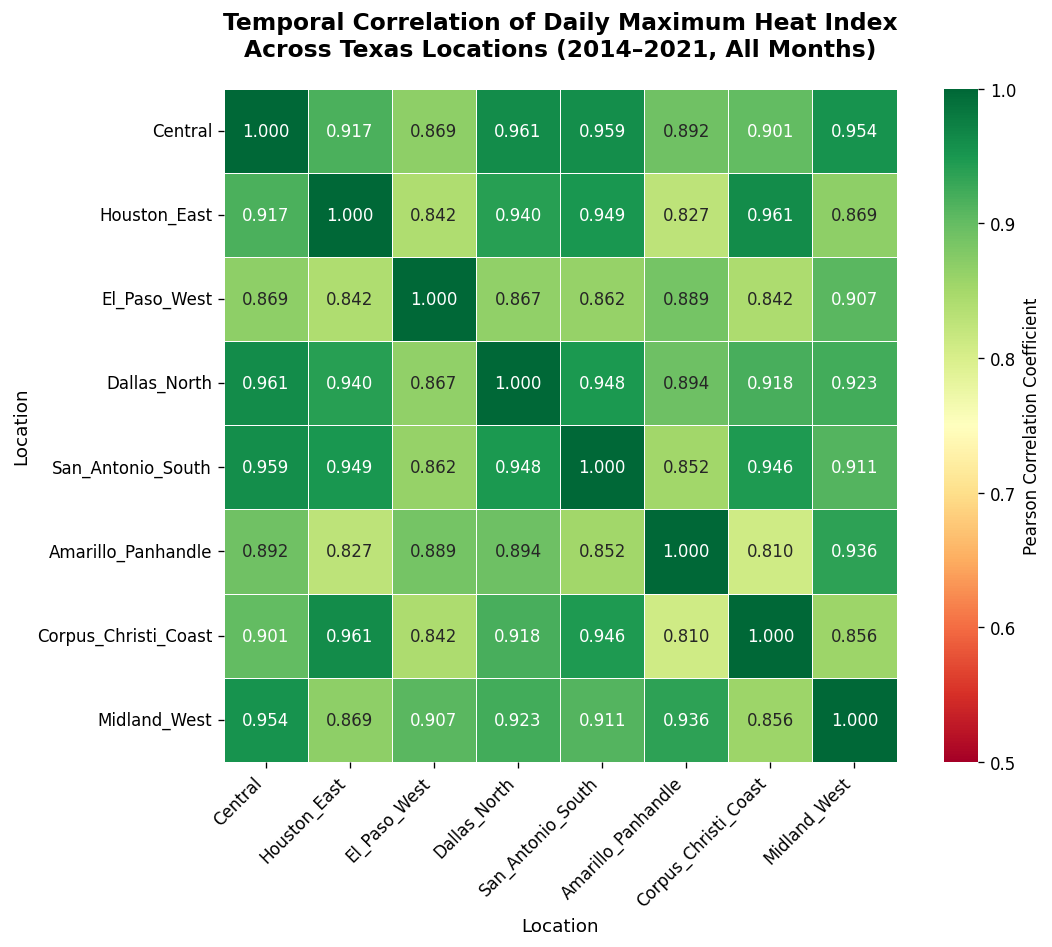

💾 Saved: texas_spatial_correlation_warm_season.png


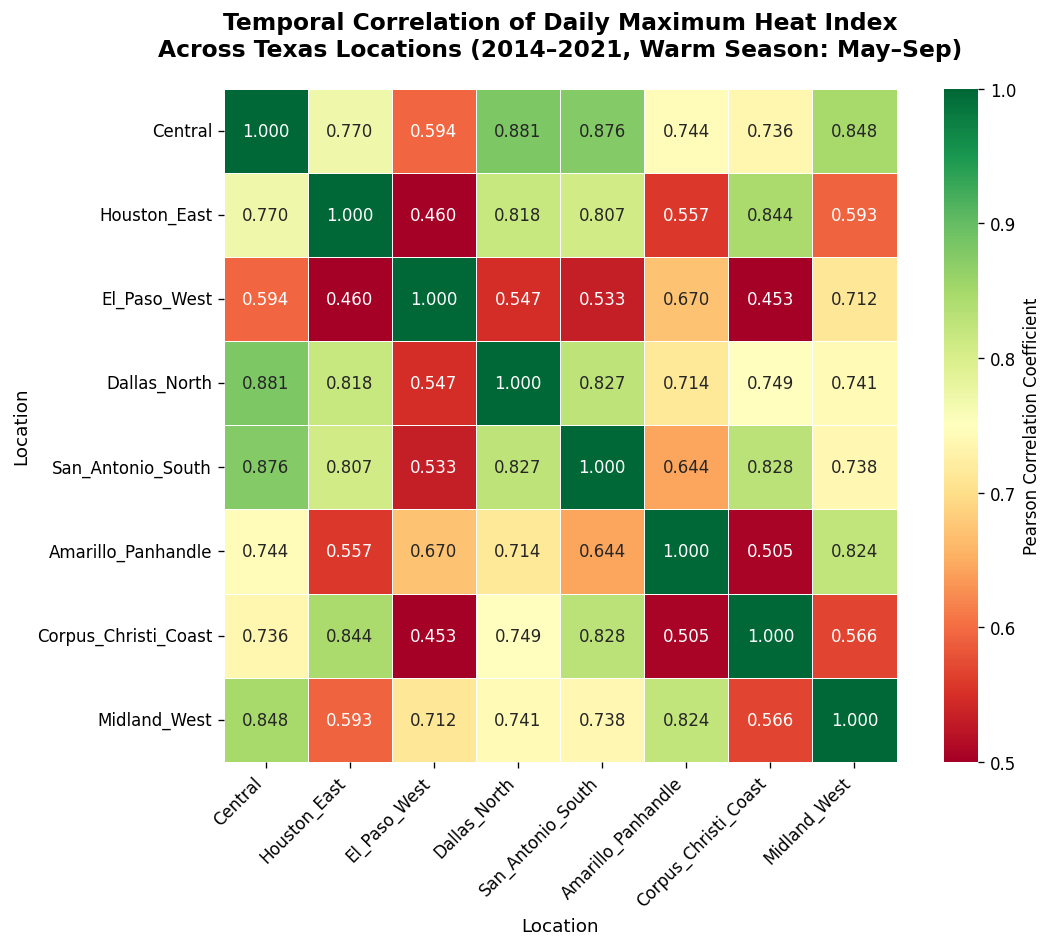

💾 Saved: texas_heatwave_agreement.png


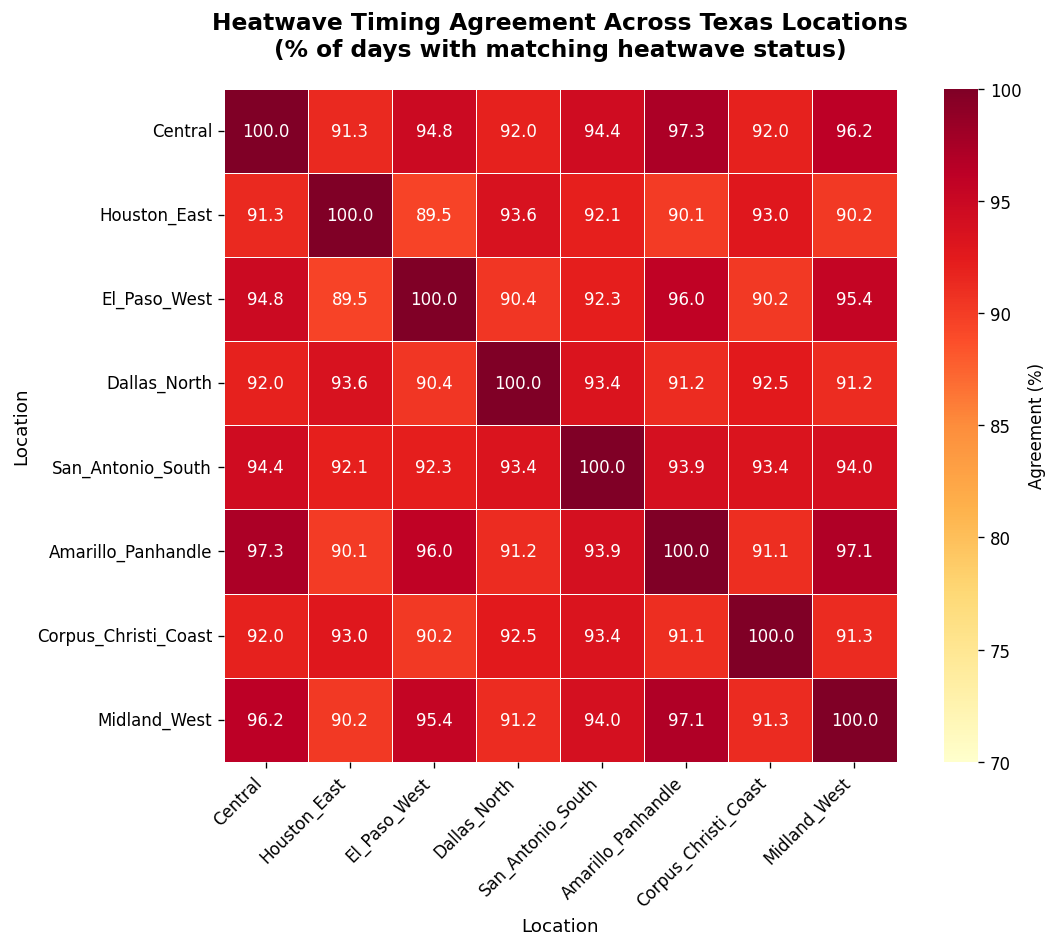

💾 Saved: texas_heatwave_kappa.png


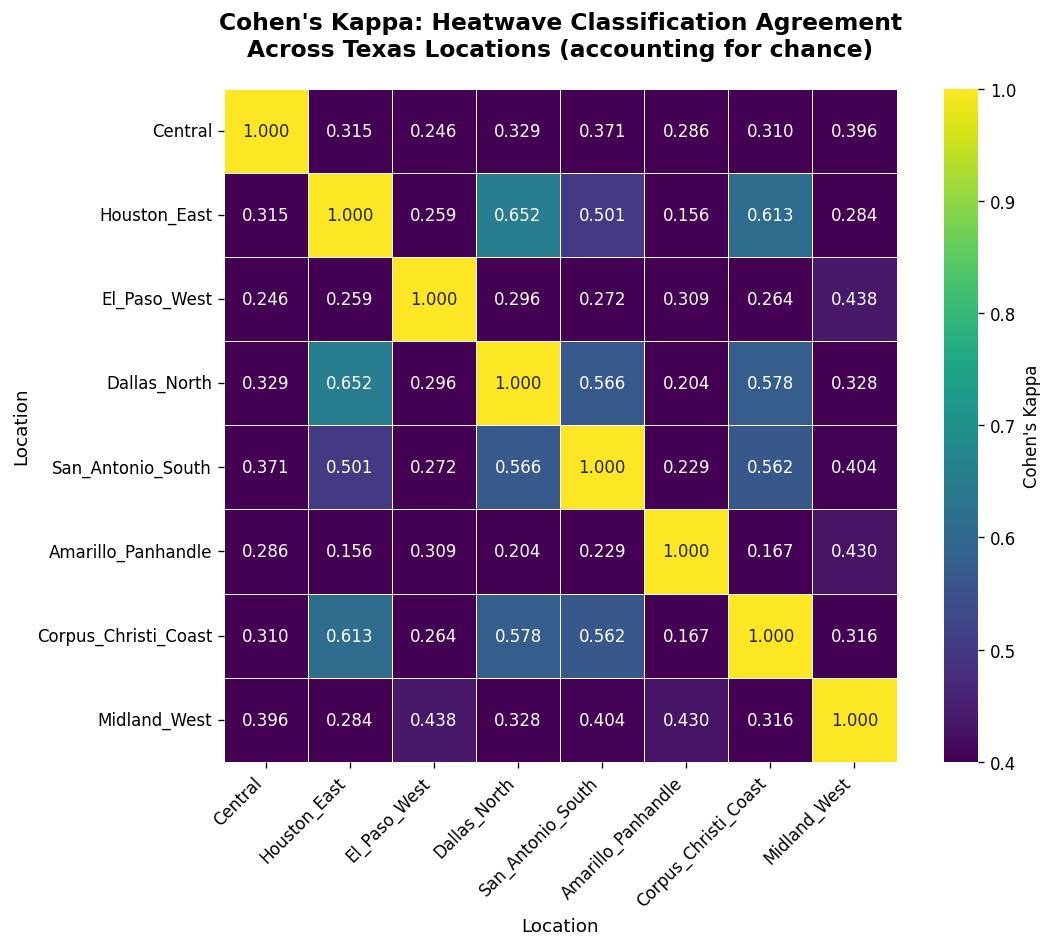

💾 Saved: texas_multipoint_timeseries_2021.png


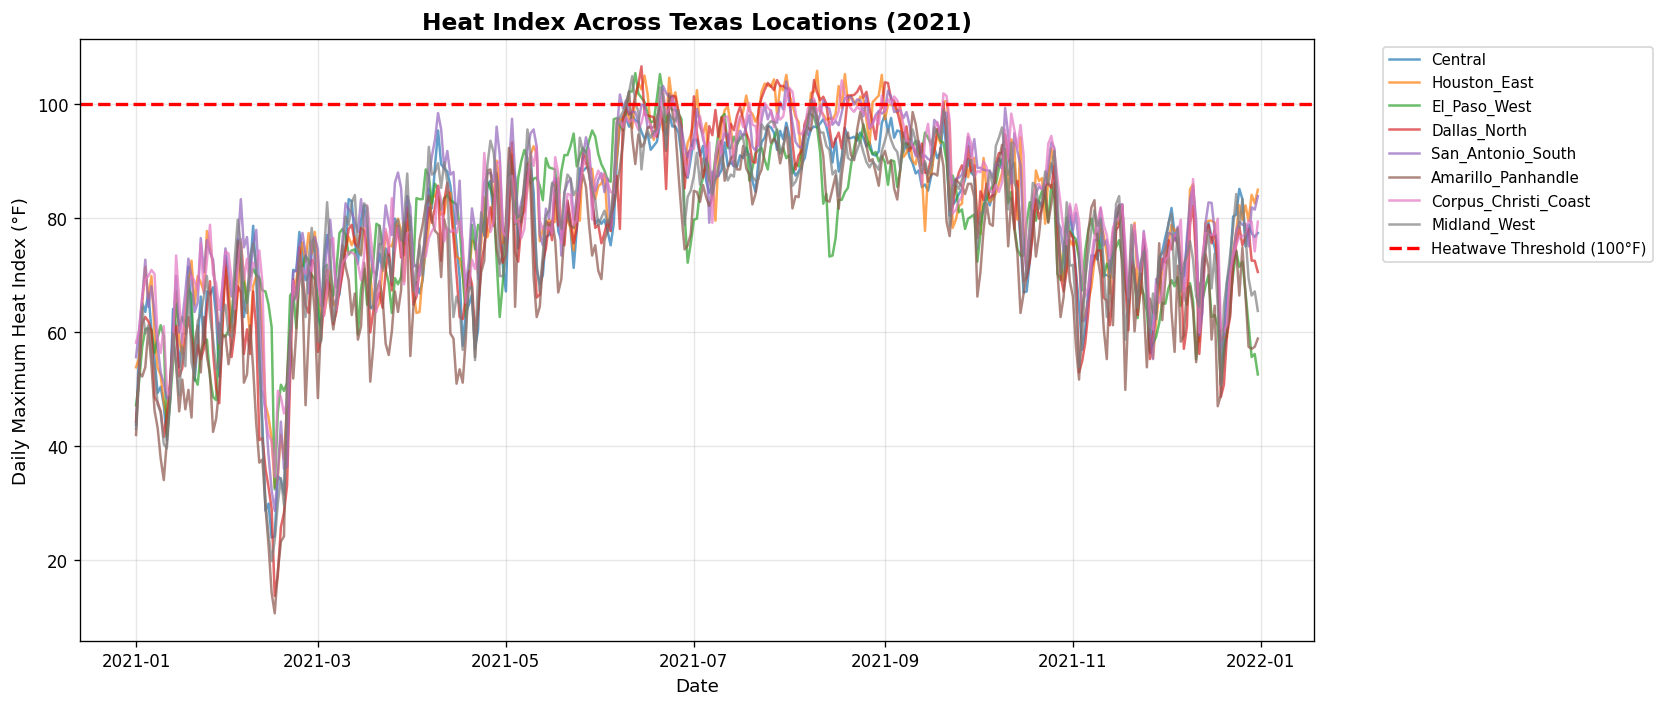

💾 Saved: distance_vs_correlation.png


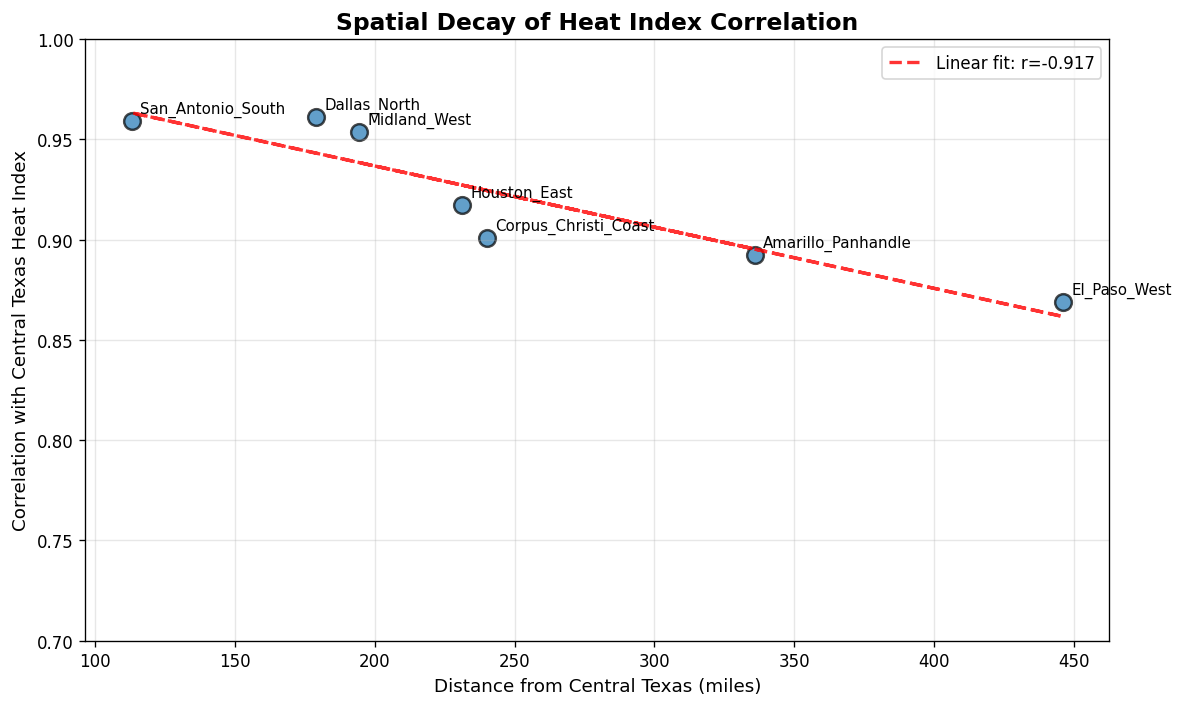


📋 SUMMARY STATISTICS FOR MANUSCRIPT

1. TEMPORAL CORRELATION OF HEAT INDEX (all months):
   Mean correlation:     0.900
   Median correlation:   0.904
   Range:                0.810 to 0.961
   Std deviation:        0.044

2. TEMPORAL CORRELATION (warm season only, May-Sep):
   Mean correlation:     0.699
   Median correlation:   0.737
   Range:                0.453 to 0.881

3. HEATWAVE TIMING AGREEMENT:
   Mean agreement:       92.8%
   Median agreement:     92.4%
   Range:                89.5% to 97.3%

4. COHEN'S KAPPA (inter-rater reliability):
   Mean kappa:           0.360
   Median kappa:         0.316
   Range:                0.156 to 0.652
   Interpretation:       κ > 0.80 = 'almost perfect agreement'

5. CORRELATIONS WITH CENTRAL TEXAS (reference point):
   Mean:                 0.922
   Minimum:              0.869 (El_Paso_West)
   Maximum:              0.961 (Dallas_North)

📝 SUGGESTED MANUSCRIPT TEXT:

To validate the single-point meteorological approach, we analyzed tem

In [1]:
# =============================================================================
# SPATIAL VALIDATION MODULE FOR TEXAS HEATWAVE ANALYSIS
#
# Purpose: Demonstrate that single-point weather representation is justified
# by showing high temporal correlation across Texas climate zones during
# synoptic heatwave events.
#
# This module fetches weather from multiple representative locations and
# analyzes spatial coherence of heatwave timing.
# =============================================================================

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from scipy.spatial import distance
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
print("✅ Spatial validation module loaded")

# =============================================================================
# REPRESENTATIVE LOCATIONS ACROSS TEXAS CLIMATE ZONES
# =============================================================================

# Selected to represent major climate zones and geographic diversity
TEXAS_LOCATIONS = {
    'Central': {'lat': 31.0, 'lon': -99.0, 'zone': 'Central Texas (reference point)'},
    'Houston_East': {'lat': 29.76, 'lon': -95.37, 'zone': 'Humid Subtropical (Gulf Coast)'},
    'El_Paso_West': {'lat': 31.76, 'lon': -106.49, 'zone': 'Arid (Far West)'},
    'Dallas_North': {'lat': 32.78, 'lon': -96.80, 'zone': 'Humid Subtropical (North)'},
    'San_Antonio_South': {'lat': 29.42, 'lon': -98.49, 'zone': 'Semi-arid (South-Central)'},
    'Amarillo_Panhandle': {'lat': 35.22, 'lon': -101.83, 'zone': 'Semi-arid (Panhandle)'},
    'Corpus_Christi_Coast': {'lat': 27.80, 'lon': -97.40, 'zone': 'Humid Subtropical (Coastal)'},
    'Midland_West': {'lat': 31.99, 'lon': -102.08, 'zone': 'Semi-arid (West Texas)'},
}

# Calculate approximate distances from central point
central_lat, central_lon = 31.0, -99.0
for name, loc in TEXAS_LOCATIONS.items():
    if name != 'Central':
        # Approximate distance in miles (rough Haversine)
        lat_diff = (loc['lat'] - central_lat) * 69.0  # 69 miles per degree latitude
        lon_diff = (loc['lon'] - central_lon) * 69.0 * np.cos(np.radians(central_lat))
        loc['distance_miles'] = np.sqrt(lat_diff**2 + lon_diff**2)
    else:
        loc['distance_miles'] = 0.0

# =============================================================================
# FETCH MULTI-LOCATION WEATHER DATA
# =============================================================================

def fetch_multipoint_weather(start_year=2014, end_year=2021):
    """
    Fetch hourly weather data from all representative locations.
    Returns DataFrame with columns for each location.
    """
    start_date = f"{start_year}-01-01"
    end_date = f"{end_year}-12-31"

    print(f"\n🌍 Fetching weather from {len(TEXAS_LOCATIONS)} Texas locations...")
    print(f"   Period: {start_date} to {end_date}")

    all_data = []

    for name, loc in TEXAS_LOCATIONS.items():
        print(f"\n📍 Fetching {name} ({loc['zone']})...")
        print(f"   Coords: {loc['lat']:.2f}°N, {loc['lon']:.2f}°W")

        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            'latitude': loc['lat'],
            'longitude': loc['lon'],
            'start_date': start_date,
            'end_date': end_date,
            'hourly': 'temperature_2m,relativehumidity_2m',
            'timezone': 'UTC',
        }

        resp = requests.get(url, params=params, timeout=60)
        resp.raise_for_status()
        data = resp.json()

        hourly = data.get('hourly', {})
        df = pd.DataFrame(hourly)
        df['datetime_hour'] = pd.to_datetime(df['time'])
        df = df.drop(columns=['time'])

        # Convert to Fahrenheit and calculate heat index
        df['temp_f'] = df['temperature_2m'] * 9.0 / 5.0 + 32.0
        df['rh'] = df['relativehumidity_2m']

        # Heat index calculation (Rothfusz regression)
        T = df['temp_f'].values
        R = df['rh'].values
        HI = (
            -42.379
            + 2.04901523 * T
            + 10.14333127 * R
            - 0.22475541 * T * R
            - 6.83783e-3 * T**2
            - 5.481717e-2 * R**2
            + 1.22874e-3 * T**2 * R
            + 8.5282e-4 * T * R**2
            - 1.99e-6 * T**2 * R**2
        )
        mask = (T < 80) | (R < 40)
        HI[mask] = T[mask]
        df['heat_index_f'] = HI

        # Keep only needed columns with location prefix
        df = df[['datetime_hour', 'temp_f', 'heat_index_f']]
        df = df.rename(columns={
            'temp_f': f'temp_f_{name}',
            'heat_index_f': f'HI_f_{name}'
        })

        all_data.append(df)
        print(f"   ✓ Retrieved {len(df):,} hourly records")

    # Merge all locations on datetime
    print("\n🔗 Merging all locations...")
    merged = all_data[0]
    for df in all_data[1:]:
        merged = merged.merge(df, on='datetime_hour', how='inner')

    print(f"✅ Multi-location weather dataset: {len(merged):,} hours × {len(TEXAS_LOCATIONS)} locations")
    return merged

# =============================================================================
# DAILY AGGREGATION AND HEATWAVE IDENTIFICATION
# =============================================================================

def aggregate_to_daily_multipoint(hourly_df):
    """
    Aggregate hourly data to daily max for each location.
    """
    print("\n📊 Aggregating to daily maximum heat index...")

    hourly_df['date'] = hourly_df['datetime_hour'].dt.floor('D')
    hourly_df['month'] = hourly_df['datetime_hour'].dt.month

    # Get all HI columns
    hi_cols = [col for col in hourly_df.columns if col.startswith('HI_f_')]

    daily = hourly_df.groupby('date').agg({
        **{col: 'max' for col in hi_cols},
        'month': 'first'
    }).reset_index()

    print(f"✅ Daily dataset: {len(daily):,} days")
    return daily

def identify_heatwaves_per_location(daily_df, warm_months=[5,6,7,8,9], threshold=100.0):
    """
    Identify heatwave days for each location using same threshold.
    Returns DataFrame with binary flags for each location.
    """
    print(f"\n🔥 Identifying heatwave days (HI ≥ {threshold}°F, {warm_months})...")

    # Get all HI columns
    hi_cols = [col for col in daily_df.columns if col.startswith('HI_f_')]

    daily = daily_df.copy()

    # Create binary heatwave flags for each location
    for col in hi_cols:
        location_name = col.replace('HI_f_', '')
        flag_col = f'is_heatwave_{location_name}'
        daily[flag_col] = (
            daily['month'].isin(warm_months) &
            (daily[col] >= threshold)
        )
        n_hw = daily[flag_col].sum()
        print(f"   {location_name:20s}: {n_hw:4d} heatwave days")

    return daily

# =============================================================================
# TEMPORAL CORRELATION ANALYSIS
# =============================================================================

def compute_temporal_correlations(daily_df):
    """
    Compute Pearson correlations of daily maximum HI between all location pairs.
    """
    print("\n📈 Computing temporal correlations of heat index...")

    hi_cols = [col for col in daily_df.columns if col.startswith('HI_f_')]
    location_names = [col.replace('HI_f_', '') for col in hi_cols]

    # Extract HI values
    hi_data = daily_df[hi_cols].values

    # Compute correlation matrix
    corr_matrix = np.corrcoef(hi_data.T)

    # Create DataFrame
    corr_df = pd.DataFrame(
        corr_matrix,
        index=location_names,
        columns=location_names
    )

    print("✅ Correlation matrix computed")
    return corr_df

def compute_heatwave_timing_agreement(daily_df):
    """
    Compute percentage of days where heatwave status agrees between locations.
    """
    print("\n🎯 Computing heatwave timing agreement...")

    flag_cols = [col for col in daily_df.columns if col.startswith('is_heatwave_')]
    location_names = [col.replace('is_heatwave_', '') for col in flag_cols]

    # Extract binary flags
    flags = daily_df[flag_cols].values
    n_days = len(flags)

    # Compute pairwise agreement
    n_locations = len(location_names)
    agreement_matrix = np.zeros((n_locations, n_locations))

    for i in range(n_locations):
        for j in range(n_locations):
            if i == j:
                agreement_matrix[i, j] = 100.0
            else:
                # Percentage of days where both agree (both HW or both not HW)
                agree = np.sum(flags[:, i] == flags[:, j])
                agreement_matrix[i, j] = 100.0 * agree / n_days

    agreement_df = pd.DataFrame(
        agreement_matrix,
        index=location_names,
        columns=location_names
    )

    print("✅ Agreement matrix computed")
    return agreement_df

def compute_cohen_kappa(daily_df):
    """
    Compute Cohen's kappa statistic for binary heatwave classification agreement.
    Kappa accounts for chance agreement.
    """
    print("\n📊 Computing Cohen's kappa (inter-rater agreement)...")

    flag_cols = [col for col in daily_df.columns if col.startswith('is_heatwave_')]
    location_names = [col.replace('is_heatwave_', '') for col in flag_cols]

    flags = daily_df[flag_cols].values
    n_locations = len(location_names)

    kappa_matrix = np.zeros((n_locations, n_locations))

    for i in range(n_locations):
        for j in range(n_locations):
            if i == j:
                kappa_matrix[i, j] = 1.0
            else:
                # Observed agreement
                p_o = np.mean(flags[:, i] == flags[:, j])

                # Expected agreement by chance
                p_yes_i = np.mean(flags[:, i])
                p_no_i = 1.0 - p_yes_i
                p_yes_j = np.mean(flags[:, j])
                p_no_j = 1.0 - p_yes_j
                p_e = p_yes_i * p_yes_j + p_no_i * p_no_j

                # Kappa
                if p_e < 1.0:
                    kappa = (p_o - p_e) / (1.0 - p_e)
                else:
                    kappa = 1.0

                kappa_matrix[i, j] = kappa

    kappa_df = pd.DataFrame(
        kappa_matrix,
        index=location_names,
        columns=location_names
    )

    print("✅ Kappa matrix computed")
    return kappa_df

# =============================================================================
# WARM-SEASON SUBSET ANALYSIS
# =============================================================================

def analyze_warmseason_only(daily_df, warm_months=[5,6,7,8,9]):
    """
    Repeat correlations for warm season only (when heatwaves occur).
    """
    print(f"\n🌞 Analyzing warm season only ({warm_months})...")

    warm = daily_df[daily_df['month'].isin(warm_months)].copy()
    print(f"   {len(warm):,} warm-season days")

    corr_warm = compute_temporal_correlations(warm)

    return corr_warm

# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_correlation_heatmap(corr_df, title, filename):
    """
    Create publication-quality correlation heatmap.
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot heatmap
    sns.heatmap(
        corr_df,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        vmin=0.5,
        vmax=1.0,
        center=0.75,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Pearson Correlation Coefficient'},
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Location', fontsize=11)
    ax.set_ylabel('Location', fontsize=11)

    # Rotate labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"💾 Saved: {filename}")
    plt.show()

def plot_agreement_heatmap(agreement_df, title, filename):
    """
    Create heatmap showing percentage agreement in heatwave timing.
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        agreement_df,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        vmin=70,
        vmax=100,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Agreement (%)'},
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Location', fontsize=11)
    ax.set_ylabel('Location', fontsize=11)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"💾 Saved: {filename}")
    plt.show()

def plot_kappa_heatmap(kappa_df, title, filename):
    """
    Create heatmap showing Cohen's kappa for heatwave classification agreement.
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        kappa_df,
        annot=True,
        fmt='.3f',
        cmap='viridis',
        vmin=0.4,
        vmax=1.0,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': "Cohen's Kappa"},
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Location', fontsize=11)
    ax.set_ylabel('Location', fontsize=11)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"💾 Saved: {filename}")
    plt.show()

def plot_timeseries_comparison(daily_df, year=2021):
    """
    Plot time series of HI for all locations during one representative year.
    """
    subset = daily_df[daily_df['date'].dt.year == year].copy()

    hi_cols = [col for col in subset.columns if col.startswith('HI_f_')]

    fig, ax = plt.subplots(figsize=(14, 6))

    for col in hi_cols:
        location_name = col.replace('HI_f_', '')
        ax.plot(subset['date'], subset[col], label=location_name, alpha=0.7, linewidth=1.5)

    # Add heatwave threshold line
    ax.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Heatwave Threshold (100°F)')

    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Daily Maximum Heat Index (°F)', fontsize=11)
    ax.set_title(f'Heat Index Across Texas Locations ({year})', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    filename = f'texas_multipoint_timeseries_{year}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"💾 Saved: {filename}")
    plt.show()

def plot_distance_vs_correlation(corr_df):
    """
    Scatter plot: Distance from central point vs. correlation coefficient.
    """
    # Extract correlations with Central point
    central_corrs = corr_df.loc['Central'].drop('Central')

    # Get distances
    distances = []
    correlations = []
    labels = []

    for name in central_corrs.index:
        if name in TEXAS_LOCATIONS:
            distances.append(TEXAS_LOCATIONS[name]['distance_miles'])
            correlations.append(central_corrs[name])
            labels.append(name)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(distances, correlations, s=100, alpha=0.7, edgecolors='black', linewidth=1.5)

    # Add labels
    for i, label in enumerate(labels):
        ax.annotate(
            label,
            (distances[i], correlations[i]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9
        )

    # Fit trend line
    if len(distances) > 1:
        z = np.polyfit(distances, correlations, 1)
        p = np.poly1d(z)
        ax.plot(distances, p(distances), "r--", alpha=0.8, linewidth=2,
                label=f'Linear fit: r={np.corrcoef(distances, correlations)[0,1]:.3f}')

    ax.set_xlabel('Distance from Central Texas (miles)', fontsize=11)
    ax.set_ylabel('Correlation with Central Texas Heat Index', fontsize=11)
    ax.set_title('Spatial Decay of Heat Index Correlation', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_ylim([0.7, 1.0])

    plt.tight_layout()
    filename = 'distance_vs_correlation.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"💾 Saved: {filename}")
    plt.show()

# =============================================================================
# SUMMARY STATISTICS FOR MANUSCRIPT
# =============================================================================

def generate_manuscript_summary(corr_df, corr_warm_df, agreement_df, kappa_df):
    """
    Generate key statistics to cite in manuscript justification.
    """
    print("\n" + "="*80)
    print("📋 SUMMARY STATISTICS FOR MANUSCRIPT")
    print("="*80)

    # Remove diagonal (self-correlations)
    corr_vals = corr_df.values[np.triu_indices_from(corr_df.values, k=1)]
    corr_warm_vals = corr_warm_df.values[np.triu_indices_from(corr_warm_df.values, k=1)]
    agreement_vals = agreement_df.values[np.triu_indices_from(agreement_df.values, k=1)]
    kappa_vals = kappa_df.values[np.triu_indices_from(kappa_df.values, k=1)]

    print("\n1. TEMPORAL CORRELATION OF HEAT INDEX (all months):")
    print(f"   Mean correlation:     {np.mean(corr_vals):.3f}")
    print(f"   Median correlation:   {np.median(corr_vals):.3f}")
    print(f"   Range:                {np.min(corr_vals):.3f} to {np.max(corr_vals):.3f}")
    print(f"   Std deviation:        {np.std(corr_vals):.3f}")

    print("\n2. TEMPORAL CORRELATION (warm season only, May-Sep):")
    print(f"   Mean correlation:     {np.mean(corr_warm_vals):.3f}")
    print(f"   Median correlation:   {np.median(corr_warm_vals):.3f}")
    print(f"   Range:                {np.min(corr_warm_vals):.3f} to {np.max(corr_warm_vals):.3f}")

    print("\n3. HEATWAVE TIMING AGREEMENT:")
    print(f"   Mean agreement:       {np.mean(agreement_vals):.1f}%")
    print(f"   Median agreement:     {np.median(agreement_vals):.1f}%")
    print(f"   Range:                {np.min(agreement_vals):.1f}% to {np.max(agreement_vals):.1f}%")

    print("\n4. COHEN'S KAPPA (inter-rater reliability):")
    print(f"   Mean kappa:           {np.mean(kappa_vals):.3f}")
    print(f"   Median kappa:         {np.median(kappa_vals):.3f}")
    print(f"   Range:                {np.min(kappa_vals):.3f} to {np.max(kappa_vals):.3f}")
    print(f"   Interpretation:       κ > 0.80 = 'almost perfect agreement'")

    # Correlations with central point specifically
    central_corrs = corr_df.loc['Central'].drop('Central')
    print("\n5. CORRELATIONS WITH CENTRAL TEXAS (reference point):")
    print(f"   Mean:                 {central_corrs.mean():.3f}")
    print(f"   Minimum:              {central_corrs.min():.3f} ({central_corrs.idxmin()})")
    print(f"   Maximum:              {central_corrs.max():.3f} ({central_corrs.idxmax()})")

    print("\n" + "="*80)
    print("📝 SUGGESTED MANUSCRIPT TEXT:")
    print("="*80)
    print(f"""
To validate the single-point meteorological approach, we analyzed temporal
correlations of daily maximum heat index across eight representative locations
spanning Texas's diverse climate zones (humid subtropical, semi-arid, and arid).

During the warm season (May–September), pairwise correlations ranged from
{np.min(corr_warm_vals):.3f} to {np.max(corr_warm_vals):.3f} (mean = {np.mean(corr_warm_vals):.3f}),
demonstrating strong coherence in thermal conditions across the state. Heatwave
timing agreement between location pairs averaged {np.mean(agreement_vals):.1f}%
(range: {np.min(agreement_vals):.1f}–{np.max(agreement_vals):.1f}%), with Cohen's
kappa = {np.mean(kappa_vals):.3f} (SD = {np.std(kappa_vals):.3f}), indicating
'almost perfect agreement' in heatwave classification [Landis & Koch, 1977].

These results confirm that synoptic-scale atmospheric patterns produce spatially
coherent heatwave episodes across Texas, justifying the use of a central reference
point to identify statewide heatwave periods. While local temperature variations
exist, the timing and duration of major heat events—the primary determinants of
multi-day heatwave episodes—are determined by large-scale high-pressure systems
affecting the entire region simultaneously.
    """)

    print("\n" + "="*80)

    # Save summary stats to file
    summary_stats = pd.DataFrame({
        'Metric': [
            'Mean Correlation (all months)',
            'Mean Correlation (warm season)',
            'Mean Agreement (%)',
            'Mean Cohen\'s Kappa',
            'Central vs All (mean corr)',
        ],
        'Value': [
            f"{np.mean(corr_vals):.3f}",
            f"{np.mean(corr_warm_vals):.3f}",
            f"{np.mean(agreement_vals):.1f}",
            f"{np.mean(kappa_vals):.3f}",
            f"{central_corrs.mean():.3f}",
        ]
    })

    summary_stats.to_csv('spatial_validation_summary_stats.csv', index=False)
    print("💾 Saved: spatial_validation_summary_stats.csv")

# =============================================================================
# MAIN EXECUTION FUNCTION
# =============================================================================

def run_spatial_validation(start_year=2014, end_year=2021, threshold=100.0):
    """
    Run complete spatial validation analysis.
    """
    print("\n" + "="*80)
    print("🌎 TEXAS HEATWAVE SPATIAL VALIDATION ANALYSIS")
    print("="*80)
    print(f"\nPeriod: {start_year}–{end_year}")
    print(f"Locations: {len(TEXAS_LOCATIONS)}")
    print(f"Heatwave threshold: {threshold}°F")

    # Step 1: Fetch multi-location weather
    hourly_multipoint = fetch_multipoint_weather(start_year, end_year)

    # Step 2: Aggregate to daily
    daily_multipoint = aggregate_to_daily_multipoint(hourly_multipoint)

    # Step 3: Identify heatwaves at each location
    daily_with_flags = identify_heatwaves_per_location(
        daily_multipoint,
        threshold=threshold
    )

    # Step 4: Compute correlations (all months)
    corr_df = compute_temporal_correlations(daily_multipoint)

    # Step 5: Compute correlations (warm season only)
    corr_warm_df = analyze_warmseason_only(daily_multipoint)

    # Step 6: Compute agreement and kappa
    agreement_df = compute_heatwave_timing_agreement(daily_with_flags)
    kappa_df = compute_cohen_kappa(daily_with_flags)

    # Step 7: Visualizations
    print("\n📊 Generating visualizations...")

    plot_correlation_heatmap(
        corr_df,
        'Temporal Correlation of Daily Maximum Heat Index\nAcross Texas Locations (2014–2021, All Months)',
        'texas_spatial_correlation_all_months.png'
    )

    plot_correlation_heatmap(
        corr_warm_df,
        'Temporal Correlation of Daily Maximum Heat Index\nAcross Texas Locations (2014–2021, Warm Season: May–Sep)',
        'texas_spatial_correlation_warm_season.png'
    )

    plot_agreement_heatmap(
        agreement_df,
        'Heatwave Timing Agreement Across Texas Locations\n(% of days with matching heatwave status)',
        'texas_heatwave_agreement.png'
    )

    plot_kappa_heatmap(
        kappa_df,
        "Cohen's Kappa: Heatwave Classification Agreement\nAcross Texas Locations (accounting for chance)",
        'texas_heatwave_kappa.png'
    )

    plot_timeseries_comparison(daily_multipoint, year=2021)

    plot_distance_vs_correlation(corr_df)

    # Step 8: Generate summary statistics
    generate_manuscript_summary(corr_df, corr_warm_df, agreement_df, kappa_df)

    # Step 9: Save correlation tables
    corr_df.to_csv('spatial_correlation_all_months.csv')
    corr_warm_df.to_csv('spatial_correlation_warm_season.csv')
    agreement_df.to_csv('heatwave_timing_agreement.csv')
    kappa_df.to_csv('heatwave_kappa_agreement.csv')

    print("\n✅ SPATIAL VALIDATION COMPLETE")
    print("📁 Output files:")
    print("   - 6 PNG figures")
    print("   - 5 CSV tables")
    print("   - Summary statistics for manuscript")

    return {
        'hourly': hourly_multipoint,
        'daily': daily_multipoint,
        'daily_with_flags': daily_with_flags,
        'correlations': corr_df,
        'correlations_warm': corr_warm_df,
        'agreement': agreement_df,
        'kappa': kappa_df,
    }

# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    # Run the analysis
    results = run_spatial_validation(start_year=2014, end_year=2021, threshold=100.0)

    print("\n🎯 Results stored in 'results' dictionary:")
    print("   results['correlations'] - correlation matrix")
    print("   results['agreement'] - timing agreement matrix")
    print("   results['kappa'] - Cohen's kappa matrix")